In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Fetch actual wind generation - January 2024
url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH"

params = {
    "fuelType": "WIND",
    "settlementDateFrom": "2024-01-01",
    "settlementDateTo": "2024-01-31",
    "format": "json"
}

response = requests.get(url, params=params)
data = response.json()

# Convert to dataframe
actuals_df = pd.DataFrame(data['data'])
actuals_df = actuals_df[['startTime', 'generation', 'fuelType']]
actuals_df['startTime'] = pd.to_datetime(actuals_df['startTime'])
actuals_df = actuals_df.sort_values('startTime').reset_index(drop=True)

print(f"Rows fetched: {len(actuals_df)}")
print(actuals_df.head())

KeyError: 'data'

In [3]:
print(data.keys())
print(type(data))
print(str(data)[:500])


dict_keys(['type', 'title', 'status', 'errors', 'traceId'])
<class 'dict'>
{'type': 'https://tools.ietf.org/html/rfc9110#section-15.5.1', 'title': 'One or more validation errors occurred.', 'status': 400, 'errors': {'': ['The date range between SettlementDateFrom and SettlementDateTo inclusive must not exceed 7 days']}, 'traceId': '00-913e1b9744e81bbcf41f94b94aec9d52-1f9a5507a180bfe4-00'}


In [4]:
# Fetch actual wind generation - January 2024 (week by week)
url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH"

all_data = []

date_ranges = [
    ("2024-01-01", "2024-01-07"),
    ("2024-01-08", "2024-01-14"),
    ("2024-01-15", "2024-01-21"),
    ("2024-01-22", "2024-01-28"),
    ("2024-01-29", "2024-01-31"),
]

for start, end in date_ranges:
    params = {
        "fuelType": "WIND",
        "settlementDateFrom": start,
        "settlementDateTo": end,
        "format": "json"
    }
    response = requests.get(url, params=params)
    data = response.json()
    all_data.extend(data['data'])
    print(f"Fetched {start} to {end} → {len(data['data'])} rows")

actuals_df = pd.DataFrame(all_data)
actuals_df = actuals_df[['startTime', 'generation', 'fuelType']]
actuals_df['startTime'] = pd.to_datetime(actuals_df['startTime'])
actuals_df = actuals_df.sort_values('startTime').reset_index(drop=True)

print(f"\nTotal rows: {len(actuals_df)}")
print(actuals_df.head())

Fetched 2024-01-01 to 2024-01-07 → 336 rows
Fetched 2024-01-08 to 2024-01-14 → 336 rows
Fetched 2024-01-15 to 2024-01-21 → 336 rows
Fetched 2024-01-22 to 2024-01-28 → 336 rows
Fetched 2024-01-29 to 2024-01-31 → 144 rows

Total rows: 1488
                  startTime  generation fuelType
0 2024-01-01 00:00:00+00:00       10402     WIND
1 2024-01-01 00:30:00+00:00       10845     WIND
2 2024-01-01 01:00:00+00:00       11218     WIND
3 2024-01-01 01:30:00+00:00       11223     WIND
4 2024-01-01 02:00:00+00:00       11234     WIND


In [5]:
# Fetch forecast wind generation - January 2024 (week by week)
url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream"

forecast_data = []

date_ranges = [
    ("2024-01-01", "2024-01-07"),
    ("2024-01-08", "2024-01-14"),
    ("2024-01-15", "2024-01-21"),
    ("2024-01-22", "2024-01-28"),
    ("2024-01-29", "2024-01-31"),
]

for start, end in date_ranges:
    params = {
        "publishDateTimeFrom": start,
        "publishDateTimeTo": end,
        "format": "json"
    }
    response = requests.get(url, params=params)
    data = response.json()
    items = data if isinstance(data, list) else data.get('data', [])
    forecast_data.extend(items)
    print(f"Fetched {start} to {end} → {len(items)} rows")

forecasts_df = pd.DataFrame(forecast_data)
forecasts_df['startTime'] = pd.to_datetime(forecasts_df['startTime'])
forecasts_df['publishTime'] = pd.to_datetime(forecasts_df['publishTime'])
forecasts_df = forecasts_df.sort_values('startTime').reset_index(drop=True)

print(f"\nTotal forecast rows: {len(forecasts_df)}")
print(forecasts_df.head())

Fetched 2024-01-01 to 2024-01-07 → 2352 rows
Fetched 2024-01-08 to 2024-01-14 → 2352 rows
Fetched 2024-01-15 to 2024-01-21 → 2352 rows
Fetched 2024-01-22 to 2024-01-28 → 2352 rows
Fetched 2024-01-29 to 2024-01-31 → 784 rows

Total forecast rows: 10192
   dataset               publishTime                 startTime  generation
0  WINDFOR 2024-01-01 07:30:00+00:00 2024-01-01 21:00:00+00:00       10065
1  WINDFOR 2024-01-01 11:30:00+00:00 2024-01-01 21:00:00+00:00       10072
2  WINDFOR 2024-01-01 22:30:00+00:00 2024-01-01 21:00:00+00:00       11736
3  WINDFOR 2024-01-01 09:30:00+00:00 2024-01-01 21:00:00+00:00       10065
4  WINDFOR 2024-01-01 04:30:00+00:00 2024-01-01 21:00:00+00:00        9432


In [6]:
# For each actual startTime, find the latest forecast
# published at least 4 hours before it (default horizon = 4h)

HORIZON_HOURS = 4

matched = []

for _, actual_row in actuals_df.iterrows():
    target_time = actual_row['startTime']
    cutoff = target_time - pd.Timedelta(hours=HORIZON_HOURS)

    # Get all forecasts for this target time
    candidates = forecasts_df[forecasts_df['startTime'] == target_time]

    # Only keep those published before cutoff
    eligible = candidates[candidates['publishTime'] <= cutoff]

    if len(eligible) == 0:
        continue

    # Pick the latest eligible forecast
    best = eligible.loc[eligible['publishTime'].idxmax()]

    matched.append({
        'startTime':        target_time,
        'actual':           actual_row['generation'],
        'forecast':         best['generation'],
        'publishTime':      best['publishTime'],
        'horizon_hrs':      (target_time - best['publishTime']).total_seconds() / 3600
    })

matched_df = pd.DataFrame(matched)
matched_df['error'] = matched_df['forecast'] - matched_df['actual']
matched_df['abs_error'] = matched_df['error'].abs()

print(f"Matched pairs: {len(matched_df)}")
print(matched_df.head())

Matched pairs: 723
                  startTime  actual  forecast               publishTime  \
0 2024-01-01 21:00:00+00:00   13953     10634 2024-01-01 15:30:00+00:00   
1 2024-01-01 22:00:00+00:00   14217     11767 2024-01-01 15:30:00+00:00   
2 2024-01-01 23:00:00+00:00   14958     14419 2024-01-01 18:30:00+00:00   
3 2024-01-02 00:00:00+00:00   14690     15361 2024-01-01 18:30:00+00:00   
4 2024-01-02 01:00:00+00:00   14592     15805 2024-01-01 18:30:00+00:00   

   horizon_hrs  error  abs_error  
0          5.5  -3319       3319  
1          6.5  -2450       2450  
2          4.5   -539        539  
3          5.5    671        671  
4          6.5   1213       1213  


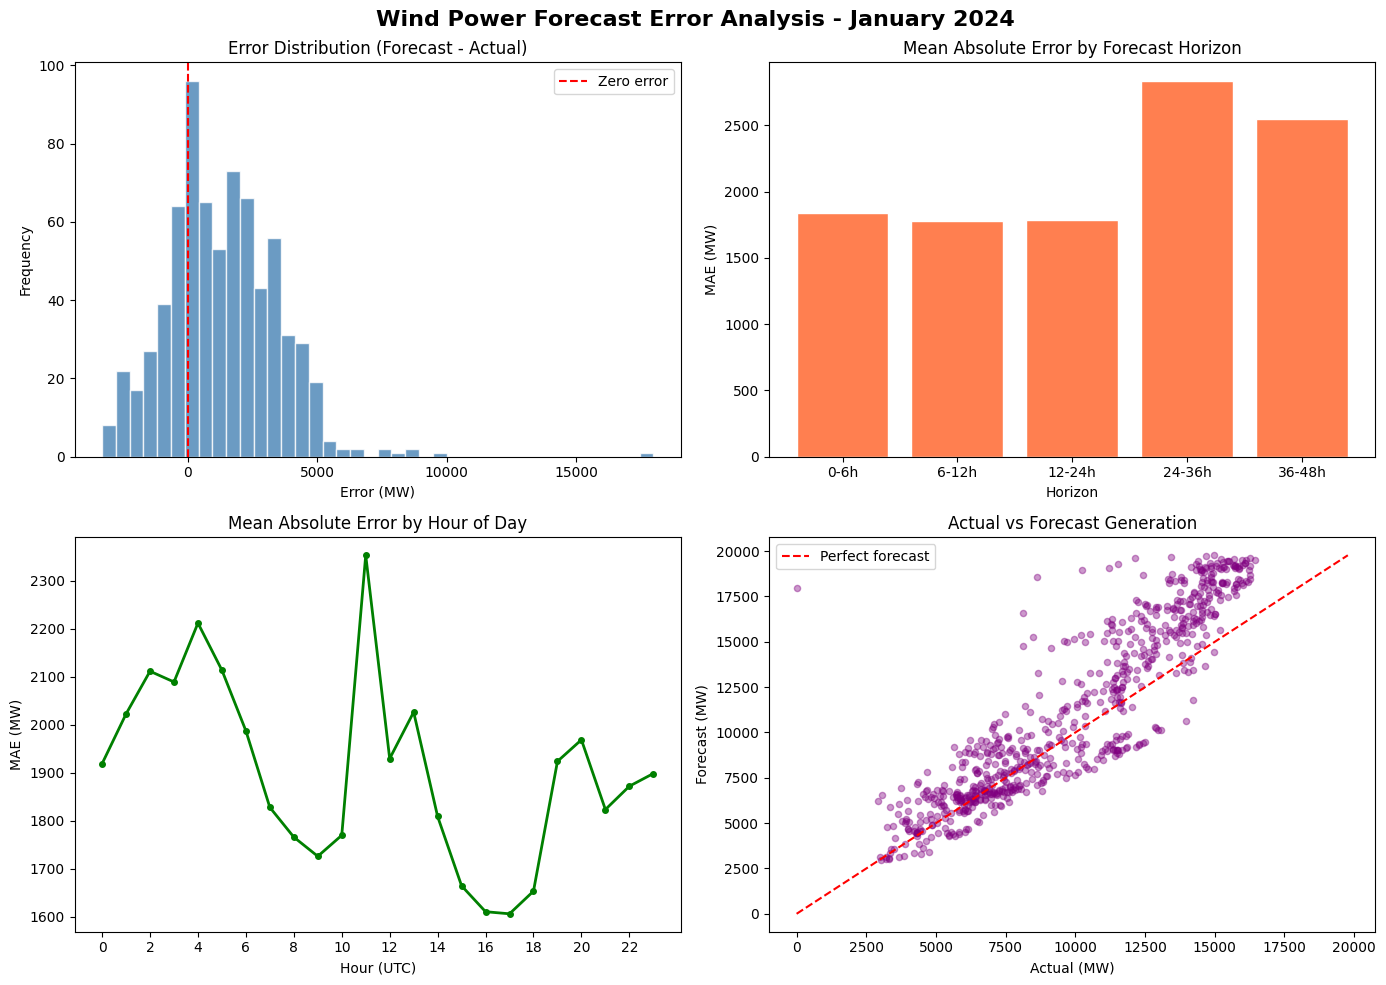

═══ Key Error Statistics ═══
Mean Error (Bias):       1310 MW
Mean Absolute Error:     1904 MW
Median Absolute Error:   1567 MW
P99 Absolute Error:      6738 MW
Max Absolute Error:      17983 MW


In [7]:
# ── Notebook 1: Forecast Error Analysis ──

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Wind Power Forecast Error Analysis - January 2024', fontsize=16, fontweight='bold')

# 1. Error distribution
axes[0,0].hist(matched_df['error'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[0,0].set_title('Error Distribution (Forecast - Actual)')
axes[0,0].set_xlabel('Error (MW)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# 2. Abs error by horizon bucket
matched_df['horizon_bucket'] = pd.cut(matched_df['horizon_hrs'],
                                       bins=[0,6,12,24,36,48],
                                       labels=['0-6h','6-12h','12-24h','24-36h','36-48h'])
horizon_stats = matched_df.groupby('horizon_bucket', observed=True)['abs_error'].mean()
axes[0,1].bar(horizon_stats.index, horizon_stats.values, color='coral', edgecolor='white')
axes[0,1].set_title('Mean Absolute Error by Forecast Horizon')
axes[0,1].set_xlabel('Horizon')
axes[0,1].set_ylabel('MAE (MW)')

# 3. Error by hour of day
matched_df['hour'] = matched_df['startTime'].dt.hour
hourly_mae = matched_df.groupby('hour')['abs_error'].mean()
axes[1,0].plot(hourly_mae.index, hourly_mae.values, color='green', linewidth=2, marker='o', markersize=4)
axes[1,0].set_title('Mean Absolute Error by Hour of Day')
axes[1,0].set_xlabel('Hour (UTC)')
axes[1,0].set_ylabel('MAE (MW)')
axes[1,0].set_xticks(range(0, 24, 2))

# 4. Actual vs Forecast scatter
axes[1,1].scatter(matched_df['actual'], matched_df['forecast'], alpha=0.4, color='purple', s=20)
max_val = max(matched_df['actual'].max(), matched_df['forecast'].max())
axes[1,1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect forecast')
axes[1,1].set_title('Actual vs Forecast Generation')
axes[1,1].set_xlabel('Actual (MW)')
axes[1,1].set_ylabel('Forecast (MW)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('forecast_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key stats
print("═══ Key Error Statistics ═══")
print(f"Mean Error (Bias):       {matched_df['error'].mean():.0f} MW")
print(f"Mean Absolute Error:     {matched_df['abs_error'].mean():.0f} MW")
print(f"Median Absolute Error:   {matched_df['abs_error'].median():.0f} MW")
print(f"P99 Absolute Error:      {matched_df['abs_error'].quantile(0.99):.0f} MW")
print(f"Max Absolute Error:      {matched_df['abs_error'].max():.0f} MW")

In [8]:
# More detailed horizon analysis
print("═══ MAE by Forecast Horizon ═══")
print(horizon_stats.round(0))

print("\n═══ Error Stats by Horizon Bucket ═══")
horizon_detail = matched_df.groupby('horizon_bucket', observed=True)['abs_error'].agg([
    'mean', 'median',
    lambda x: x.quantile(0.99)
]).round(0)
horizon_detail.columns = ['MAE', 'Median AE', 'P99 AE']
print(horizon_detail)

print("\n═══ Horizon distribution in our data ═══")
print(matched_df['horizon_bucket'].value_counts().sort_index())

═══ MAE by Forecast Horizon ═══
horizon_bucket
0-6h      1837.0
6-12h     1775.0
12-24h    1783.0
24-36h    2833.0
36-48h    2546.0
Name: abs_error, dtype: float64

═══ Error Stats by Horizon Bucket ═══
                   MAE  Median AE  P99 AE
horizon_bucket                           
0-6h            1837.0     1374.0  5030.0
6-12h           1775.0     1372.0  5250.0
12-24h          1783.0     1641.0  5752.0
24-36h          2833.0     1886.0  9353.0
36-48h          2546.0     2414.0  3702.0

═══ Horizon distribution in our data ═══
horizon_bucket
0-6h      130
6-12h     234
12-24h    270
24-36h     49
36-48h     40
Name: count, dtype: int64


## Notebook 1 — Forecast Error Analysis

### What I did
I matched each actual wind generation reading with the best available forecast
made at least 4 hours before that time. This gave me 723 matched pairs across
January 2024 to analyze.

### Key findings

**The model over-forecasts more than it under-forecasts**
The mean error came out at +1310 MW — positive means the forecast was higher
than actual generation. So on average, the model is a bit optimistic about
how much wind there will be.

**Error grows with forecast horizon — but the big jump is after 24 hours**
Short term forecasts (0-12h) have a MAE around 1800 MW which stays fairly
consistent. But once you go beyond 24 hours the error jumps to 2833 MW.
This makes intuitive sense — weather is harder to predict the further
ahead you look, and wind is especially sensitive to this.

**Mid-morning has the highest error**
Looking at error by hour of day, around 10am UTC is where the model
struggles most. This could be because wind patterns shift as daytime
heating kicks in, making them harder to predict.

**Extreme errors are a real concern**
The P99 error is 6738 MW — meaning 1 in 100 forecasts is off by more
than that. The worst single error was 17,983 MW which is enormous.
For grid operators this matters a lot because they need backup power
ready for exactly these situations. A 6-7 GW surprise is not something
you can ignore when managing national electricity supply.

### Overall conclusion
The model is decent at short horizons but gets less reliable beyond 24 hours.
The consistent over-forecasting bias also means grid operators should probably
apply a small downward correction to forecasts when planning backup capacity.

## Notebook 2 — Reliable Wind Power Recommendation


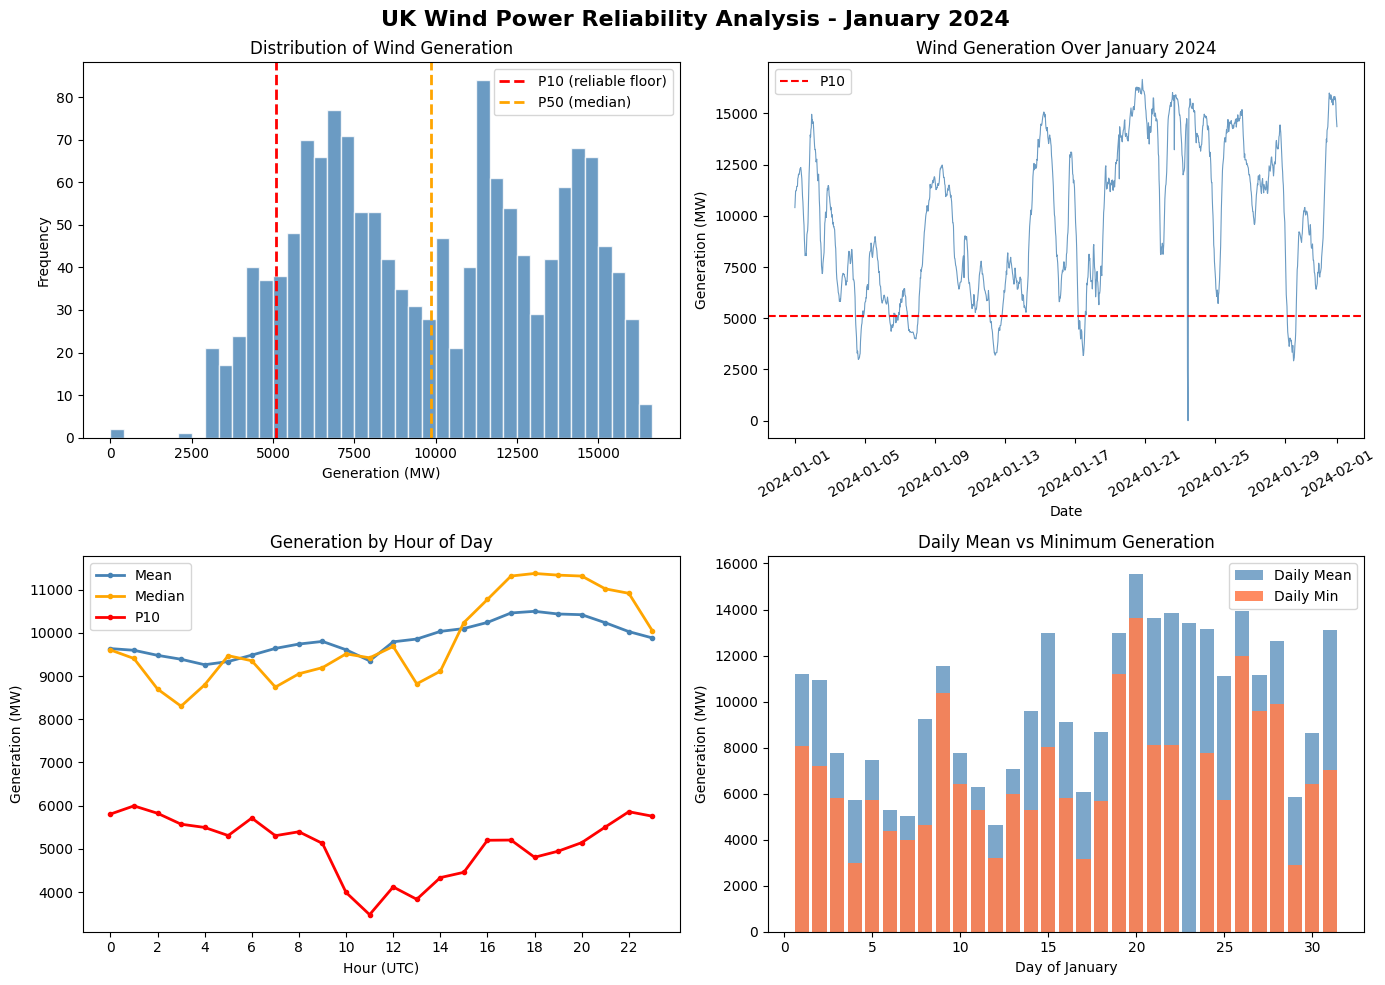

═══ Wind Generation Statistics ═══
Mean Generation:     9849 MW
Median Generation:   9864 MW
P10 (reliable floor):5088 MW
P25:                 6732 MW
Min Generation:      0 MW
Max Generation:      16662 MW

Hours below 5000 MW: 142 out of 1488
Hours below 3000 MW: 5 out of 1488


In [9]:
# ── Notebook 2: Reliable Wind Power Analysis ──

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('UK Wind Power Reliability Analysis - January 2024', fontsize=16, fontweight='bold')

# 1. Distribution of actual generation
axes[0,0].hist(actuals_df['generation'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(actuals_df['generation'].quantile(0.10), color='red', linestyle='--', linewidth=2, label='P10 (reliable floor)')
axes[0,0].axvline(actuals_df['generation'].quantile(0.50), color='orange', linestyle='--', linewidth=2, label='P50 (median)')
axes[0,0].set_title('Distribution of Wind Generation')
axes[0,0].set_xlabel('Generation (MW)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# 2. Generation over time
axes[0,1].plot(actuals_df['startTime'], actuals_df['generation'], color='steelblue', linewidth=0.8, alpha=0.8)
axes[0,1].axhline(actuals_df['generation'].quantile(0.10), color='red', linestyle='--', linewidth=1.5, label='P10')
axes[0,1].set_title('Wind Generation Over January 2024')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Generation (MW)')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Generation by hour of day
actuals_df['hour'] = actuals_df['startTime'].dt.hour
hourly = actuals_df.groupby('hour')['generation'].agg(['mean', 'median',
    lambda x: x.quantile(0.10)]).round(0)
hourly.columns = ['mean', 'median', 'p10']
axes[1,0].plot(hourly.index, hourly['mean'],   color='steelblue', linewidth=2, label='Mean', marker='o', markersize=3)
axes[1,0].plot(hourly.index, hourly['median'], color='orange',    linewidth=2, label='Median', marker='o', markersize=3)
axes[1,0].plot(hourly.index, hourly['p10'],    color='red',       linewidth=2, label='P10', marker='o', markersize=3)
axes[1,0].set_title('Generation by Hour of Day')
axes[1,0].set_xlabel('Hour (UTC)')
axes[1,0].set_ylabel('Generation (MW)')
axes[1,0].legend()
axes[1,0].set_xticks(range(0, 24, 2))

# 4. Generation by day of month
actuals_df['day'] = actuals_df['startTime'].dt.day
daily = actuals_df.groupby('day')['generation'].agg(['mean', 'min']).round(0)
axes[1,1].bar(daily.index, daily['mean'], color='steelblue', alpha=0.7, label='Daily Mean')
axes[1,1].bar(daily.index, daily['min'],  color='coral',     alpha=0.9, label='Daily Min')
axes[1,1].set_title('Daily Mean vs Minimum Generation')
axes[1,1].set_xlabel('Day of January')
axes[1,1].set_ylabel('Generation (MW)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('wind_reliability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Key stats
print("═══ Wind Generation Statistics ═══")
print(f"Mean Generation:     {actuals_df['generation'].mean():.0f} MW")
print(f"Median Generation:   {actuals_df['generation'].median():.0f} MW")
print(f"P10 (reliable floor):{actuals_df['generation'].quantile(0.10):.0f} MW")
print(f"P25:                 {actuals_df['generation'].quantile(0.25):.0f} MW")
print(f"Min Generation:      {actuals_df['generation'].min():.0f} MW")
print(f"Max Generation:      {actuals_df['generation'].max():.0f} MW")
print(f"\nHours below 5000 MW: {(actuals_df['generation'] < 5000).sum()} out of {len(actuals_df)}")
print(f"Hours below 3000 MW: {(actuals_df['generation'] < 3000).sum()} out of {len(actuals_df)}")

## Recommendation — How Much Wind Power Can We Reliably Expect?

### My Recommendation: 5000 MW as the reliable floor

Based on the January 2024 data, I would recommend that grid operators
plan around **5000 MW** as the reliable wind contribution to the grid.

### Reasoning

Wind power is an excellent source of energy but it cannot be treated
as a standalone baseload power source. Here is why:

**The 0 MW problem**
In January 2024 — which is actually one of the best months for UK wind —
there were moments where generation dropped to completely 0 MW. If grid
operators relied entirely on wind, this would mean a complete blackout
requiring instant backup. This is unacceptable for national electricity supply.

**Why 5000 MW?**
The P10 value is 5088 MW — meaning 90% of the time, wind produces at
least this much. This is a conservative but honest number. Planning
around the mean (9849 MW) would be dangerous because half the time
generation falls below that.

**January is a good month — other months could be worse**
The UK gets its strongest winds in winter. If January already shows
complete wind stops, summer months are likely even less reliable.
So 5000 MW might even be optimistic as an annual reliable figure.

### Final Recommendation

Wind power is a fantastic and important part of the UK energy mix and
I strongly recommend continued investment in it. However, grid operators
must always maintain sufficient backup capacity — gas peakers, battery
storage, or interconnectors — to cover the moments when wind drops.

A realistic and safe planning assumption is **5000 MW of reliable wind
contribution**, with backup systems ready to cover the remaining demand
at all times.